<a href="https://colab.research.google.com/github/pratixa5548/using-decision-tree-to-predict-diabetes-readmission-probability/blob/main/diabetes_readmission_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 0. IMPORT ALL REQUIRED LIBRARIES
# ============================================================

import io
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc
)

from imblearn.over_sampling import SMOTE

from scipy import stats

warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================================
# 1. LOAD THE DATASET
# ============================================================

uploaded = files.upload()

df = pd.read_csv(
    io.BytesIO(uploaded['diabetic_data.csv'])
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nFirst 10 rows:")
display(df.head(10))

Saving diabetic_data.csv to diabetic_data.csv
Dataset loaded successfully.
Shape: (101766, 50)

First 10 rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
# ============================================================
# 2. CHECK DATA TYPES
# ============================================================

print("\nData types:")
display(df.dtypes)


Data types:


,0
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [4]:
# ============================================================
# 3. CHECK UNKNOWN VALUES
# ============================================================

for col in df.columns:
    if df[col].dtype == object:
        count_unknown = (df[col] == '?').sum()
        if count_unknown > 0:
            print(col, count_unknown)

print(
    "Unknown/Invalid gender:",
    (df['gender'] == 'Unknown/Invalid').sum()
)

race 2273
weight 98569
payer_code 40256
medical_specialty 49949
diag_1 21
diag_2 358
diag_3 1423
Unknown/Invalid gender: 3


In [5]:
# ============================================================
# 4. REMOVE COLUMNS WITH EXCESSIVE / UNUSABLE INFORMATION
# ============================================================

df = df.drop(
    ['weight', 'payer_code', 'medical_specialty'],
    axis=1
)

print("Shape after dropping columns:", df.shape)

Shape after dropping columns: (101766, 47)


In [6]:
# ============================================================
# 5. REMOVE RECORDS WITH UNKNOWN CRITICAL INFORMATION
# ============================================================

drop_idx = set()

# Missing diagnosis information
drop_idx.update(
    df.index[
        (df['diag_1'] == '?') &
        (df['diag_2'] == '?') &
        (df['diag_3'] == '?')
    ]
)

drop_idx.update(
    df.index[df['diag_1'] == '?']
)

drop_idx.update(
    df.index[df['diag_2'] == '?']
)

drop_idx.update(
    df.index[df['diag_3'] == '?']
)

# Missing race
drop_idx.update(
    df.index[df['race'] == '?']
)

# Hospice / expired / other disposition code
drop_idx.update(
    df.index[df['discharge_disposition_id'] == 11]
)

# Invalid gender
drop_idx.update(
    df.index[df['gender'] == 'Unknown/Invalid']
)

print("Number of rows removed:", len(drop_idx))

# Keep remaining rows
df = df.loc[~df.index.isin(drop_idx)].copy()

print("Shape after removing invalid records:", df.shape)

Number of rows removed: 5320
Shape after removing invalid records: (96446, 47)


In [7]:
# ============================================================
# 6. REMOVE VERY RARE MEDICATION FEATURES
# ============================================================

rare_medication_columns = [
    'citoglipton',
    'examide',
    'acetohexamide',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone'
]

df = df.drop(
    columns=rare_medication_columns,
    errors='ignore'
)

print("Shape after removing rare medication columns:", df.shape)

Shape after removing rare medication columns: (96446, 42)


In [8]:
# ============================================================
# 7. VERIFY REMAINING UNKNOWN VALUES
# ============================================================

for col in df.columns:
    if df[col].dtype == object:
        count_unknown = (df[col] == '?').sum()
        if count_unknown > 0:
            print(col, count_unknown)

print(
    "Unknown/Invalid gender:",
    (df['gender'] == 'Unknown/Invalid').sum()
)

Unknown/Invalid gender: 0


In [9]:
# ============================================================
# 8. CREATE SERVICE UTILIZATION FEATURE
# ============================================================

df['service_utilization'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)

display(
    df[
        [
            'number_outpatient',
            'number_emergency',
            'number_inpatient',
            'service_utilization'
        ]
    ].head()
)

,number_outpatient,number_emergency,number_inpatient,service_utilization
1,0,0,0,0
2,2,0,1,3
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0


In [10]:
# ============================================================
# 9. CREATE NUMBER OF MEDICATION CHANGES
# ============================================================

keys = [
    'metformin',
    'repaglinide',
    'nateglinide',
    'chlorpropamide',
    'glimepiride',
    'glipizide',
    'glyburide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'miglitol',
    'insulin',
    'glyburide-metformin',
    'tolazamide',
    'metformin-pioglitazone',
    'glipizide-metformin',
    'troglitazone',
    'tolbutamide'
]

df['numchange'] = 0

for col in keys:
    if col in df.columns:
        df['numchange'] += (
            ~df[col].isin(['No', 'Steady'])
        ).astype(int)

print("Distribution of medication changes:")
print(df['numchange'].value_counts().sort_index())

Distribution of medication changes:
numchange
0    70142
1    24922
2     1271
3      106
4        5
Name: count, dtype: int64


In [11]:
# ============================================================
# 10. RE-ENCODE ADMISSION VARIABLES
# ============================================================

# Admission type
df['admission_type_id'] = df['admission_type_id'].replace({
    2: 1,
    7: 1,
    6: 5,
    8: 5
})

# Discharge disposition
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace({
    6: 1,
    8: 1,
    9: 1,
    13: 1,
    3: 2,
    4: 2,
    5: 2,
    14: 2,
    22: 2,
    23: 2,
    24: 2,
    12: 10,
    15: 10,
    16: 10,
    17: 10,
    25: 18,
    26: 18
})

# Admission source
df['admission_source_id'] = df['admission_source_id'].replace({
    2: 1,
    3: 1,
    5: 4,
    6: 4,
    10: 4,
    22: 4,
    25: 4,
    15: 9,
    17: 9,
    20: 9,
    21: 9,
    13: 11,
    14: 11
})

print("Admission variables re-encoded.")

Admission variables re-encoded.


In [12]:
# ============================================================
# 11. ENCODE BINARY VARIABLES
# ============================================================

df['change'] = df['change'].replace({
    'Ch': 1,
    'No': 0
})

df['gender'] = df['gender'].replace({
    'Male': 1,
    'Female': 0
})

df['diabetesMed'] = df['diabetesMed'].replace({
    'Yes': 1,
    'No': 0
})

for col in keys:
    if col in df.columns:
        df[col] = df[col].replace({
            'No': 0,
            'Steady': 1,
            'Up': 1,
            'Down': 1
        })

print(df[['gender', 'change', 'diabetesMed']].head())

   gender  change  diabetesMed
1       0       1            1
2       0       0            1
3       1       1            1
4       1       1            1
5       1       0            1


In [13]:
# ============================================================
# 12. ENCODE A1C AND GLUCOSE RESULTS
# ============================================================

df['A1Cresult'] = df['A1Cresult'].replace({
    '>7': 1,
    '>8': 1,
    'Norm': 0,
    'None': -99
})

df['max_glu_serum'] = df['max_glu_serum'].replace({
    '>200': 1,
    '>300': 1,
    'Norm': 0,
    'None': -99
})

print("A1C result distribution:")
print(df['A1Cresult'].value_counts())

print("\nGlucose result distribution:")
print(df['max_glu_serum'].value_counts())

A1C result distribution:
A1Cresult
1.0    11247
0.0     4806
Name: count, dtype: int64

Glucose result distribution:
max_glu_serum
1.0    2579
0.0    2510
Name: count, dtype: int64


In [14]:
# ============================================================
# 13. ENCODE AGE
# ============================================================

for i in range(10):
    age_range = f'[{10*i}-{10*(i+1)})'
    df['age'] = df['age'].replace(
        age_range,
        i + 1
    )

print(df['age'].value_counts().sort_index())

age
1        64
2       466
3      1471
4      3538
5      9208
6     16546
7     21521
8     24815
9     16223
10     2594
Name: count, dtype: int64


In [15]:
# ============================================================
# 14. CREATE BINARY TARGET
# ============================================================

print("Original readmission distribution:")
print(df['readmitted'].value_counts())

df['readmitted'] = df['readmitted'].replace({
    '>30': 0,
    '<30': 1,
    'NO': 0
})

df['readmitted'] = df['readmitted'].astype(int)

print("\nBinary readmission distribution:")
print(df['readmitted'].value_counts())

print("\nTarget proportions:")
print(df['readmitted'].value_counts(normalize=True))

Original readmission distribution:
readmitted
NO     50731
>30    34649
<30    11066
Name: count, dtype: int64

Binary readmission distribution:
readmitted
0    85380
1    11066
Name: count, dtype: int64

Target proportions:
readmitted
0    0.885262
1    0.114738
Name: proportion, dtype: float64


In [16]:
# ============================================================
# 15. CREATE DIAGNOSTIC HIERARCHICAL FEATURES
# ============================================================

for diag in ['diag_1', 'diag_2', 'diag_3']:

    df[f'level1_{diag}'] = df[diag]
    df[f'level2_{diag}'] = df[diag]

    # V and E codes are handled as non-numeric diagnostic groups
    mask_ve = df[diag].astype(str).str.startswith(('V', 'E'))

    df.loc[mask_ve, f'level1_{diag}'] = 0
    df.loc[mask_ve, f'level2_{diag}'] = 0

    # Replace unknown values
    df[f'level1_{diag}'] = (
        df[f'level1_{diag}']
        .replace('?', -1)
    )

    df[f'level2_{diag}'] = (
        df[f'level2_{diag}']
        .replace('?', -1)
    )

    # Convert to numeric
    df[f'level1_{diag}'] = pd.to_numeric(
        df[f'level1_{diag}'],
        errors='coerce'
    )

    df[f'level2_{diag}'] = pd.to_numeric(
        df[f'level2_{diag}'],
        errors='coerce'
    )

In [17]:
# ============================================================
# 16. CREATE LEVEL 1 DIAGNOSIS GROUPS
# ============================================================

def diagnosis_level1(code):
    if pd.isna(code):
        return 0

    code = float(code)

    if (390 <= code < 460) or np.floor(code) == 785:
        return 1

    elif (460 <= code < 520) or np.floor(code) == 786:
        return 2

    elif (520 <= code < 580) or np.floor(code) == 787:
        return 3

    elif np.floor(code) == 250:
        return 4

    elif 800 <= code < 1000:
        return 5

    elif 710 <= code < 740:
        return 6

    elif (580 <= code < 630) or np.floor(code) == 788:
        return 7

    elif 140 <= code < 240:
        return 8

    else:
        return 0


for diag in ['diag_1', 'diag_2', 'diag_3']:

    df[f'level1_{diag}'] = (
        df[f'level1_{diag}']
        .apply(diagnosis_level1)
        .astype(int)
    )

print(
    df[
        [
            'level1_diag_1',
            'level1_diag_2',
            'level1_diag_3'
        ]
    ].head()
)

   level1_diag_1  level1_diag_2  level1_diag_3
1              0              4              0
2              0              4              0
3              0              4              1
4              8              8              4
5              1              1              4


In [18]:
# ============================================================
# 16A. STANDARDIZE DIAGNOSIS COLUMN NAMES
# ============================================================

df.rename(columns={
    'level1_diag_1': 'level1_diag1',
    'level1_diag_2': 'level1_diag2',
    'level1_diag_3': 'level1_diag3',
    'level2_diag_1': 'level2_diag1',
    'level2_diag_2': 'level2_diag2',
    'level2_diag_3': 'level2_diag3'
}, inplace=True)

In [19]:
# ============================================================
# 17. CREATE LEVEL 2 DIAGNOSIS GROUPS
# ============================================================

def diagnosis_level2(code):
    if pd.isna(code):
        return 0

    code = float(code)

    if 390 <= code < 399:
        return 1

    elif 401 <= code < 415:
        return 2

    elif 415 <= code < 460:
        return 3

    elif np.floor(code) == 785:
        return 4

    elif 460 <= code < 489:
        return 5

    elif 490 <= code < 497:
        return 6

    elif 500 <= code < 520:
        return 7

    elif np.floor(code) == 786:
        return 8

    elif 520 <= code < 530:
        return 9

    elif 530 <= code < 544:
        return 10

    elif 550 <= code < 554:
        return 11

    elif 555 <= code < 580:
        return 12

    elif np.floor(code) == 787:
        return 13

    elif np.floor(code) == 250:
        return 14

    elif 800 <= code < 1000:
        return 15

    elif 710 <= code < 740:
        return 16

    elif 580 <= code < 630:
        return 17

    elif np.floor(code) == 788:
        return 18

    elif 140 <= code < 240:
        return 19

    elif 240 <= code < 280 and np.floor(code) != 250:
        return 20

    elif (680 <= code < 710) or np.floor(code) == 782:
        return 21

    elif 290 <= code < 320:
        return 22

    else:
        return 0


for col in [
    'level2_diag1',
    'level2_diag2',
    'level2_diag3'
]:

    df[col] = (
        df[col]
        .apply(diagnosis_level2)
        .astype(int)
    )

print(
    df[
        [
            'level1_diag1',
            'level1_diag2',
            'level1_diag3',
            'level2_diag1',
            'level2_diag2',
            'level2_diag3'
        ]
    ].head()
)

   level1_diag1  level1_diag2  level1_diag3  level2_diag1  level2_diag2  \
1             0             4             0            20            14   
2             0             4             0             0            14   
3             0             4             1             0            14   
4             8             8             4            19            19   
5             1             1             4             2             2   

   level2_diag3  
1            20  
2             0  
3             2  
4            14  
5            14  


In [20]:
# ============================================================
# 18. REMOVE DUPLICATE PATIENT RECORDS
# ============================================================

df2 = df.drop_duplicates(
    subset=['patient_nbr'],
    keep='first'
).copy()

print("Original cleaned dataset:", df.shape)
print("Unique-patient dataset:", df2.shape)

Original cleaned dataset: (96446, 50)
Unique-patient dataset: (67580, 50)


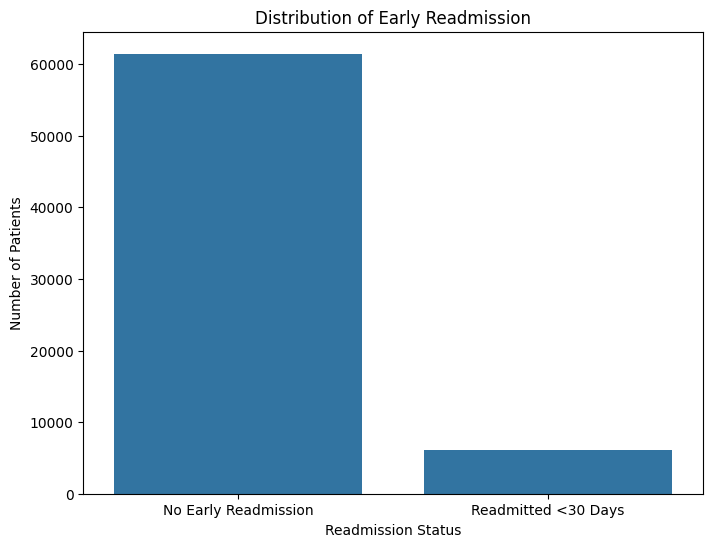

In [21]:
# ============================================================
# 19. READMISSION DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    x='readmitted',
    data=df2
)

plt.xticks(
    [0, 1],
    ['No Early Readmission', 'Readmitted <30 Days']
)

plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.title('Distribution of Early Readmission')

plt.show()

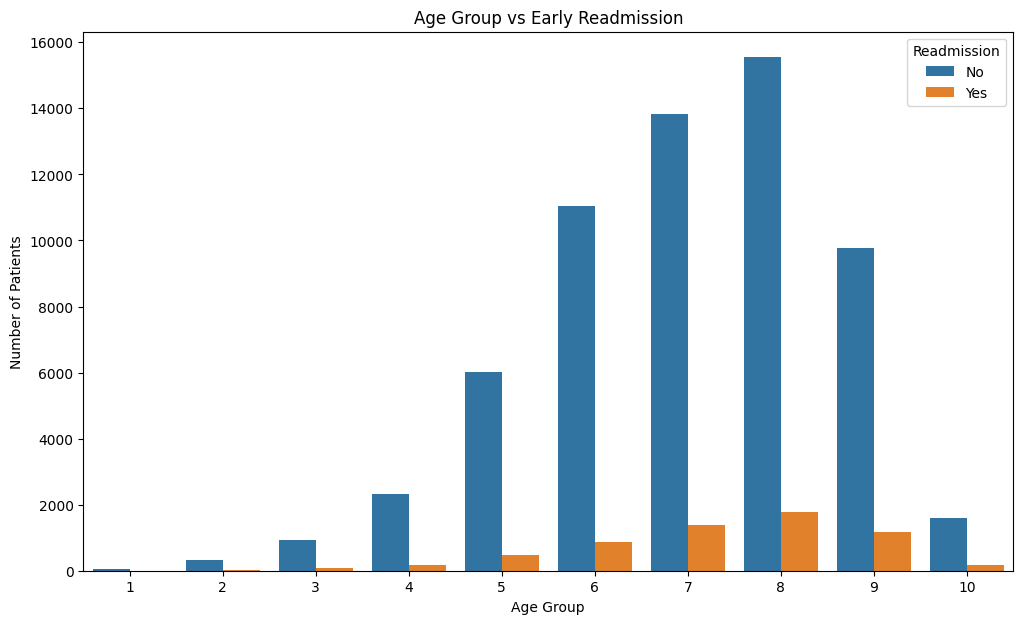

In [22]:
# ============================================================
# 20. AGE VS READMISSION
# ============================================================

plt.figure(figsize=(12, 7))

sns.countplot(
    x='age',
    hue='readmitted',
    data=df2
)

plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.title('Age Group vs Early Readmission')

plt.legend(
    title='Readmission',
    labels=['No', 'Yes']
)

plt.show()

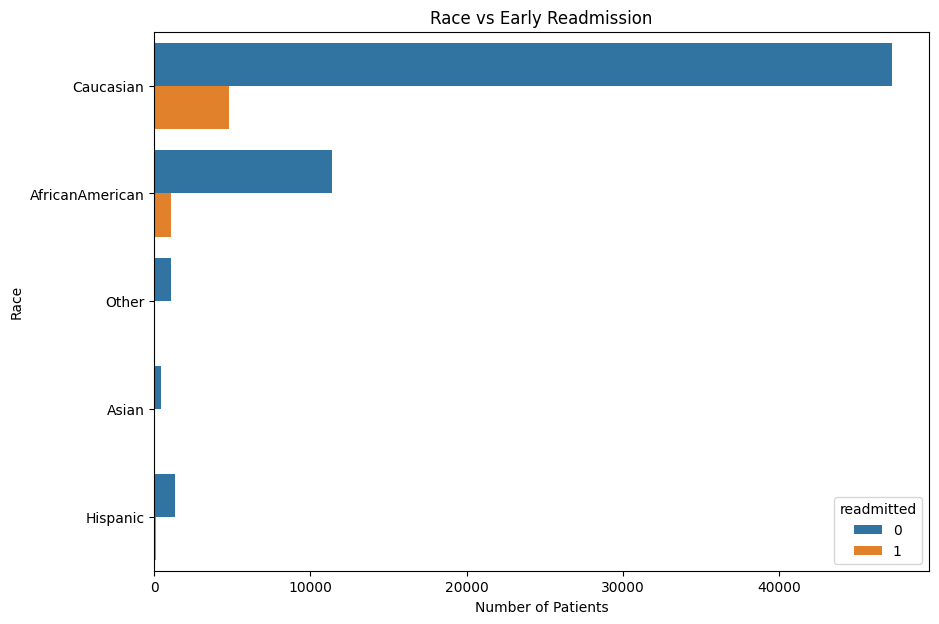

In [23]:
# ============================================================
# 21. RACE VS READMISSION
# ============================================================

plt.figure(figsize=(10, 7))

sns.countplot(
    y='race',
    hue='readmitted',
    data=df2
)

plt.xlabel('Number of Patients')
plt.ylabel('Race')
plt.title('Race vs Early Readmission')

plt.show()

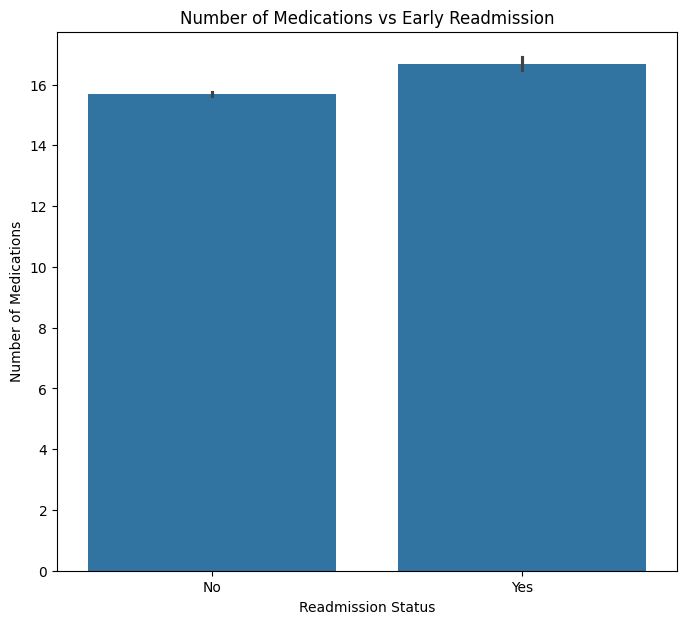

In [24]:
# ============================================================
# 22. MEDICATIONS VS READMISSION
# ============================================================

plt.figure(figsize=(8, 7))

sns.barplot(
    x='readmitted',
    y='num_medications',
    data=df2
)

plt.xlabel('Readmission Status')
plt.ylabel('Number of Medications')
plt.title('Number of Medications vs Early Readmission')

plt.xticks(
    [0, 1],
    ['No', 'Yes']
)

plt.show()

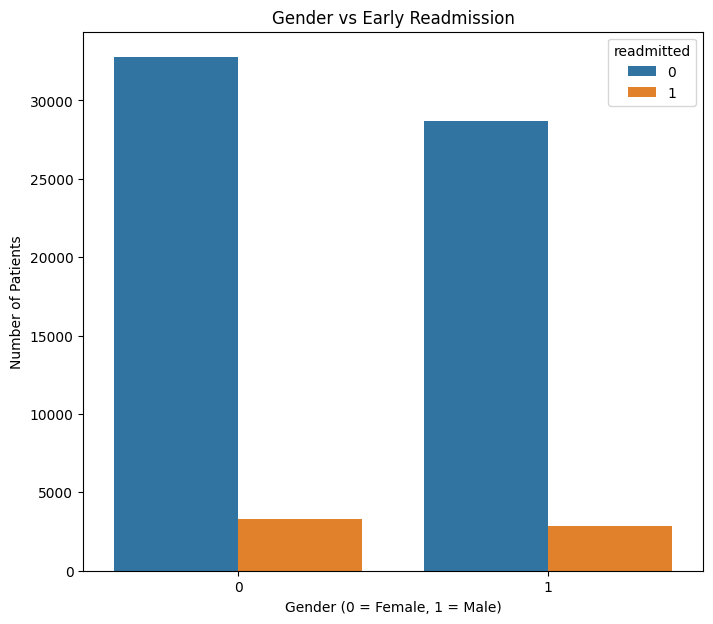

In [25]:
# ============================================================
# 23. GENDER VS READMISSION
# ============================================================

plt.figure(figsize=(8, 7))

sns.countplot(
    x='gender',
    hue='readmitted',
    data=df2
)

plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Number of Patients')
plt.title('Gender vs Early Readmission')

plt.show()

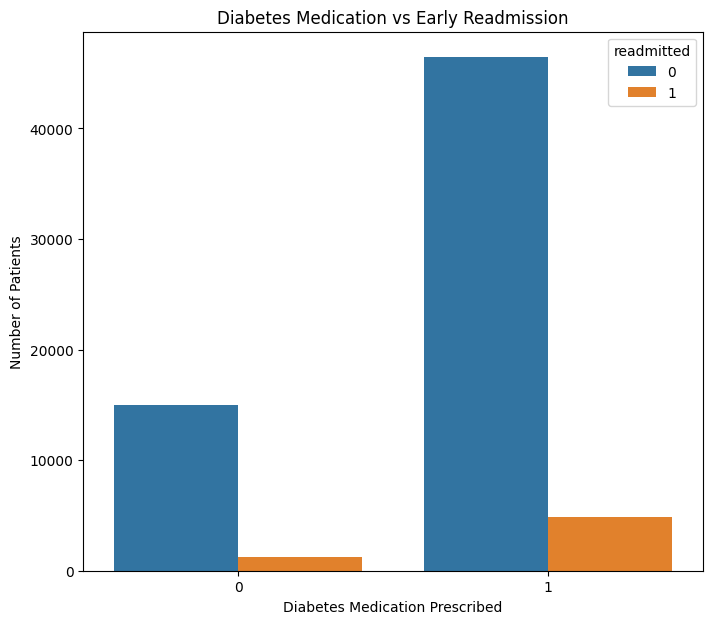

In [26]:
# ============================================================
# 24. DIABETES MEDICATION VS READMISSION
# ============================================================

plt.figure(figsize=(8, 7))

sns.countplot(
    x='diabetesMed',
    hue='readmitted',
    data=df2
)

plt.xlabel('Diabetes Medication Prescribed')
plt.ylabel('Number of Patients')
plt.title('Diabetes Medication vs Early Readmission')

plt.show()

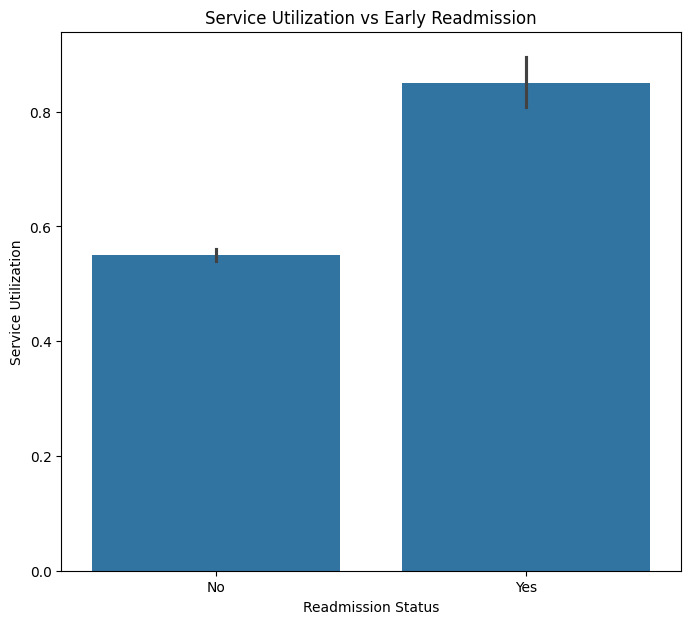

In [27]:
# ============================================================
# 25. SERVICE UTILIZATION VS READMISSION
# ============================================================

plt.figure(figsize=(8, 7))

sns.barplot(
    x='readmitted',
    y='service_utilization',
    data=df2
)

plt.xlabel('Readmission Status')
plt.ylabel('Service Utilization')
plt.title('Service Utilization vs Early Readmission')

plt.xticks(
    [0, 1],
    ['No', 'Yes']
)

plt.show()

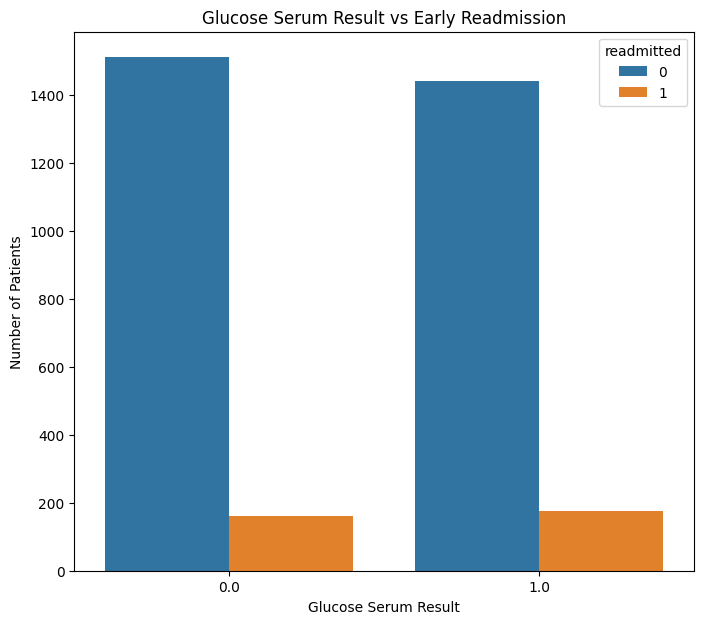

In [28]:
# ============================================================
# 26. GLUCOSE RESULT VS READMISSION
# ============================================================

plt.figure(figsize=(8, 7))

sns.countplot(
    x='max_glu_serum',
    hue='readmitted',
    data=df2
)

plt.xlabel('Glucose Serum Result')
plt.ylabel('Number of Patients')
plt.title('Glucose Serum Result vs Early Readmission')

plt.show()

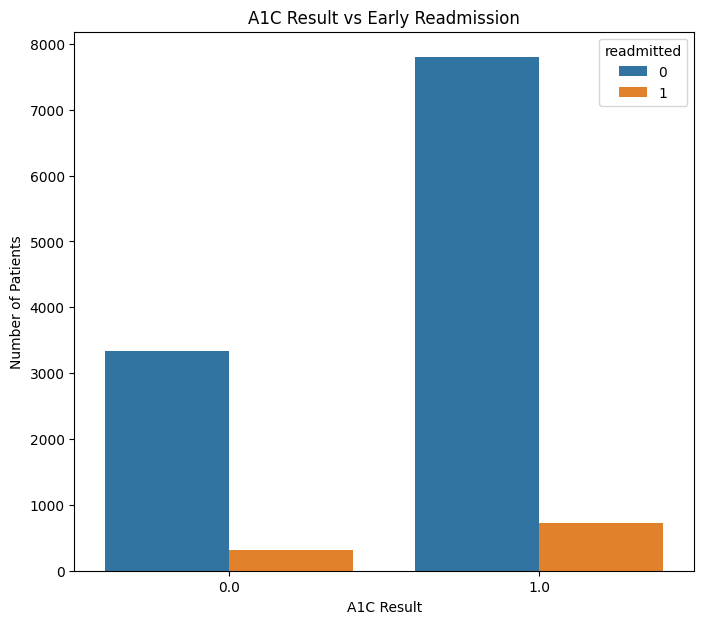

In [29]:
# ============================================================
# 27. A1C VS READMISSION
# ============================================================

plt.figure(figsize=(8, 7))

sns.countplot(
    x='A1Cresult',
    hue='readmitted',
    data=df2
)

plt.xlabel('A1C Result')
plt.ylabel('Number of Patients')
plt.title('A1C Result vs Early Readmission')

plt.show()

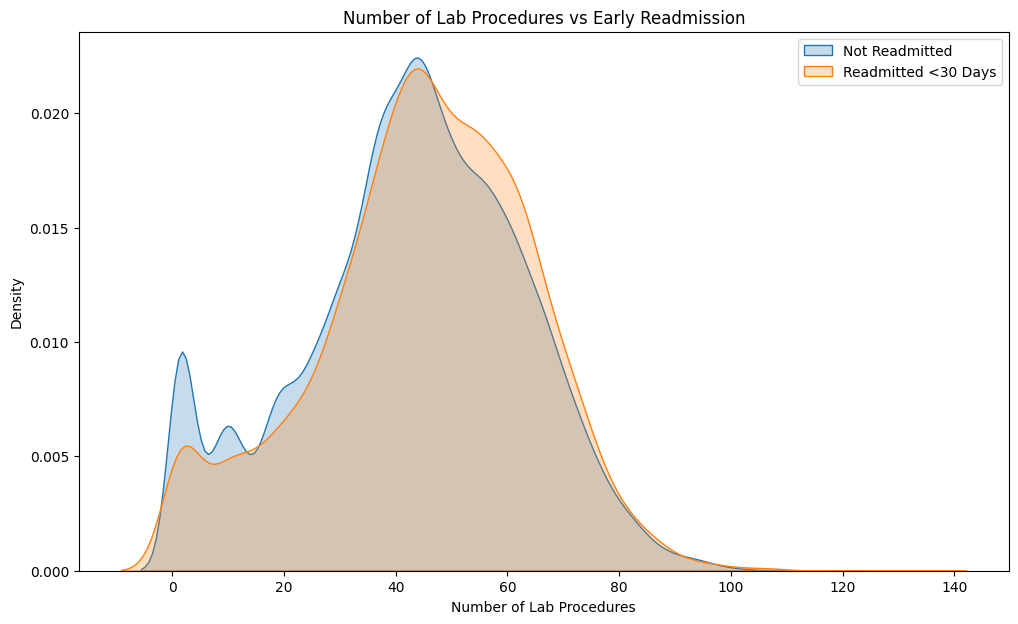

In [30]:
# ============================================================
# 28. LAB PROCEDURES VS READMISSION
# ============================================================

plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df2.loc[df2['readmitted'] == 0],
    x='num_lab_procedures',
    fill=True,
    label='Not Readmitted'
)

sns.kdeplot(
    data=df2.loc[df2['readmitted'] == 1],
    x='num_lab_procedures',
    fill=True,
    label='Readmitted <30 Days'
)

plt.xlabel('Number of Lab Procedures')
plt.ylabel('Density')
plt.title('Number of Lab Procedures vs Early Readmission')
plt.legend()

plt.show()

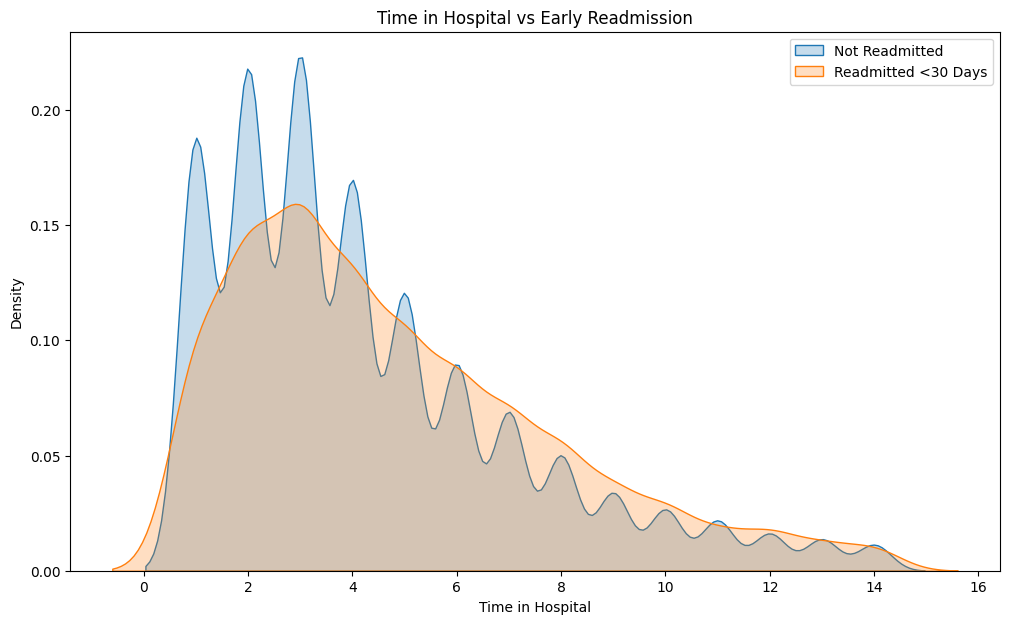

In [31]:
# ============================================================
# 29. TIME IN HOSPITAL VS READMISSION
# ============================================================

plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df2.loc[df2['readmitted'] == 0],
    x='time_in_hospital',
    fill=True,
    label='Not Readmitted'
)

sns.kdeplot(
    data=df2.loc[df2['readmitted'] == 1],
    x='time_in_hospital',
    fill=True,
    label='Readmitted <30 Days'
)

plt.xlabel('Time in Hospital')
plt.ylabel('Density')
plt.title('Time in Hospital vs Early Readmission')
plt.legend()

plt.show()

In [32]:
# ============================================================
# 30. CREATE TOTAL MEDICATION COUNT
# ============================================================

df2['nummed'] = 0

for col in keys:
    if col in df2.columns:
        df2['nummed'] += df2[col]

print(df2['nummed'].value_counts().sort_index())

nummed
0    16267
1    29976
2    14864
3     5444
4      976
5       49
6        4
Name: count, dtype: int64


In [33]:
# ============================================================
# 31. LOG TRANSFORM SKEWED UTILIZATION FEATURES
# ============================================================

utilization_columns = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

for col in utilization_columns:
    df2[col + '_log1p'] = np.log1p(
        df2[col]
    )

print(
    df2[
        [
            'number_outpatient',
            'number_outpatient_log1p',
            'number_emergency',
            'number_emergency_log1p',
            'number_inpatient',
            'number_inpatient_log1p'
        ]
    ].head()
)

   number_outpatient  number_outpatient_log1p  number_emergency  \
1                  0                 0.000000                 0   
2                  2                 1.098612                 0   
3                  0                 0.000000                 0   
4                  0                 0.000000                 0   
5                  0                 0.000000                 0   

   number_emergency_log1p  number_inpatient  number_inpatient_log1p  
1                     0.0                 0                0.000000  
2                     0.0                 1                0.693147  
3                     0.0                 0                0.000000  
4                     0.0                 0                0.000000  
5                     0.0                 0                0.000000  


In [34]:
# ============================================================
# 32. REMOVE REDUNDANT UTILIZATION FEATURES
# ============================================================

df2 = df2.drop(
    [
        'number_outpatient',
        'number_inpatient',
        'number_emergency',
        'service_utilization'
    ],
    axis=1,
    errors='ignore'
)

print("Shape:", df2.shape)

Shape: (67580, 50)


In [35]:
# ============================================================
# 33. CREATE INTERACTION FEATURES
# ============================================================

interaction_terms = [
    ('num_medications', 'time_in_hospital'),
    ('num_medications', 'num_procedures'),
    ('time_in_hospital', 'num_lab_procedures'),
    ('num_medications', 'num_lab_procedures'),
    ('num_medications', 'number_diagnoses'),
    ('age', 'number_diagnoses'),
    ('change', 'num_medications'),
    ('number_diagnoses', 'time_in_hospital'),
    ('num_medications', 'numchange')
]

for feature1, feature2 in interaction_terms:

    name = feature1 + '|' + feature2

    df2[name] = (
        df2[feature1] *
        df2[feature2]
    )

print(
    df2[
        [
            'num_medications',
            'time_in_hospital',
            'num_medications|time_in_hospital'
        ]
    ].head()
)

   num_medications  time_in_hospital  num_medications|time_in_hospital
1               18                 3                                54
2               13                 2                                26
3               16                 2                                32
4                8                 1                                 8
5               16                 3                                48


In [36]:
# ============================================================
# 34. SUMMARY STATISTICS
# ============================================================

numerical_columns = df2.select_dtypes(
    include=['number']
).columns

summary_stats = {
    'Feature': [],
    'Mean': [],
    'Median': [],
    'Mode': [],
    'Standard Deviation': []
}

for column in numerical_columns:

    summary_stats['Feature'].append(column)

    summary_stats['Mean'].append(
        df2[column].mean()
    )

    summary_stats['Median'].append(
        df2[column].median()
    )

    summary_stats['Mode'].append(
        df2[column].mode().iloc[0]
        if not df2[column].mode().empty
        else np.nan
    )

    summary_stats['Standard Deviation'].append(
        df2[column].std()
    )

summary_df = pd.DataFrame(summary_stats)

display(summary_df)

,Feature,Mean,Median,Mode,Standard Deviation
0,encounter_id,1.575726e+08,145603866.0,12522.0,1.001928e+08
1,patient_nbr,5.554583e+07,50035104.0,135.0,3.942691e+07
2,gender,4.666617e-01,0.0,0.0,4.988910e-01
3,age,7.086061e+00,7.0,8.0,1.558345e+00
4,admission_type_id,1.850355e+00,1.0,1.0,1.374651e+00
5,discharge_disposition_id,2.071101e+00,1.0,1.0,3.722144e+00
6,admission_source_id,5.011142e+00,7.0,7.0,2.926710e+00
7,time_in_hospital,4.311394e+00,4.0,3.0,2.947819e+00
8,num_lab_procedures,4.296574e+01,44.0,1.0,1.995305e+01
9,num_procedures,1.436194e+00,1.0,0.0,1.758365e+00


In [37]:
# ============================================================
# 35. CHECK SKEWNESS AND KURTOSIS
# ============================================================

numeric_columns = df2.select_dtypes(
    include=['number']
).columns

skewness_table = pd.DataFrame({
    'Feature': numeric_columns,
    'Skewness': [
        df2[col].skew()
        for col in numeric_columns
    ],
    'Kurtosis': [
        df2[col].kurtosis()
        for col in numeric_columns
    ]
})

display(
    skewness_table.sort_values(
        by='Skewness',
        key=lambda x: abs(x),
        ascending=False
    ).head(20)
)

,Feature,Skewness,Kurtosis
31,metformin-pioglitazone,259.961536,67580.000000
26,troglitazone,150.082200,22523.333185
30,glipizide-metformin,98.243139,9649.999860
21,tolbutamide,64.968743,4219.062472
25,miglitol,58.104648,3374.250028
27,tolazamide,49.098665,2408.750143
17,chlorpropamide,31.478064,988.897789
24,acarbose,18.584099,343.378888
29,glyburide-metformin,11.878850,139.111186
16,nateglinide,11.689370,134.645363


In [38]:
# ============================================================
# 36. PREPARE CATEGORICAL FEATURES
# ============================================================

categorical_columns = [
    'race',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'max_glu_serum',
    'A1Cresult',
    'level1_diag1'
]

# Convert categorical columns to string so that
# get_dummies treats them correctly
for col in categorical_columns:
    df2[col] = df2[col].astype(str)

print("Categorical columns prepared.")

Categorical columns prepared.


In [39]:
# ============================================================
# 37. ONE-HOT ENCODING
# ============================================================

df_pd = pd.get_dummies(
    df2,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Encoded dataset shape:", df_pd.shape)

display(df_pd.head().T)

Encoded dataset shape: (67580, 84)


,1,2,3,4,5
encounter_id,149190,64410,500364,16680,35754
patient_nbr,55629189,86047875,82442376,42519267,82637451
gender,0,0,1,1,1
age,2,3,4,5,6
time_in_hospital,3,2,2,1,3
...,...,...,...,...,...
level1_diag1_4,0,0,0,0,0
level1_diag1_5,0,0,0,0,0
level1_diag1_6,0,0,0,0,0
level1_diag1_7,0,0,0,0,0


In [40]:
# ============================================================
# 38. REMOVE IDENTIFIER VARIABLES
# ============================================================

df_pd = df_pd.drop(
    [
        'encounter_id',
        'patient_nbr',
        'diag_1',
        'diag_2',
        'diag_3',
        'level2_diag1',
        'level1_diag2',
        'level2_diag2',
        'level1_diag3',
        'level2_diag3'
    ],
    axis=1,
    errors='ignore'
)

print("Shape after removing identifiers and unused diagnosis columns:")
print(df_pd.shape)

Shape after removing identifiers and unused diagnosis columns:
(67580, 74)


In [41]:
# ============================================================
# 39. CHECK DATA TYPES
# ============================================================

print(df_pd.dtypes)

gender                int64
age                   int64
time_in_hospital      int64
num_lab_procedures    int64
num_procedures        int64
                      ...  
level1_diag1_4        int64
level1_diag1_5        int64
level1_diag1_6        int64
level1_diag1_7        int64
level1_diag1_8        int64
Length: 74, dtype: object


In [42]:
# ============================================================
# 40. HANDLE REMAINING MISSING VALUES
# ============================================================

missing_values = df_pd.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

# Fill numerical missing values with median
numeric_cols = df_pd.select_dtypes(
    include=['number']
).columns

for col in numeric_cols:

    if df_pd[col].isnull().any():

        df_pd[col] = df_pd[col].fillna(
            df_pd[col].median()
        )

print(
    "Remaining missing values:",
    df_pd.isnull().sum().sum()
)

Series([], dtype: int64)
Remaining missing values: 0


In [43]:
# ============================================================
# 40. HANDLE REMAINING MISSING VALUES
# ============================================================

missing_values = df_pd.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(ascending=False)
)

# Fill numerical missing values with median
numeric_cols = df_pd.select_dtypes(
    include=['number']
).columns

for col in numeric_cols:

    if df_pd[col].isnull().any():

        df_pd[col] = df_pd[col].fillna(
            df_pd[col].median()
        )

print(
    "Remaining missing values:",
    df_pd.isnull().sum().sum()
)

Series([], dtype: int64)
Remaining missing values: 0


In [44]:
# ============================================================
# 42. DEFINE FEATURES AND TARGET
# ============================================================

X = df_pd.drop(
    columns=['readmitted']
).copy()

y = df_pd['readmitted'].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(Counter(y))

Feature matrix shape: (67580, 73)
Target shape: (67580,)

Target distribution:
Counter({0: 61451, 1: 6129})


In [46]:
# ============================================================
# 43. CHECK FEATURE MATRIX
# ============================================================

print("Number of features:", X.shape[1])

print("\nFeature names:")
print(list(X.columns))

Number of features: 73

Feature names:
['gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone', 'change', 'diabetesMed', 'numchange', 'nummed', 'number_outpatient_log1p', 'number_emergency_log1p', 'number_inpatient_log1p', 'num_medications|time_in_hospital', 'num_medications|num_procedures', 'time_in_hospital|num_lab_procedures', 'num_medications|num_lab_procedures', 'num_medications|number_diagnoses', 'age|number_diagnoses', 'change|num_medications', 'number_diagnoses|time_in_hospital', 'num_medications|numchange', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'admission_type_id_3', 'admission_type_id_4', 'admission_type_id_5',

In [47]:
# ============================================================
# 44. TRAIN / TEST SPLIT
# ============================================================

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("Training set:", X_train_raw.shape)
print("Testing set:", X_test_raw.shape)

print("\nTraining target distribution:")
print(Counter(y_train))

print("\nTesting target distribution:")
print(Counter(y_test))

Training set: (54064, 73)
Testing set: (13516, 73)

Training target distribution:
Counter({0: 49161, 1: 4903})

Testing target distribution:
Counter({0: 12290, 1: 1226})


In [48]:
# ============================================================
# 45. APPLY SMOTE ONLY TO TRAINING DATA
# ============================================================

print("Before SMOTE:")
print(Counter(y_train))

smt = SMOTE(
    random_state=20
)

X_train_smote, y_train_smote = smt.fit_resample(
    X_train_raw,
    y_train
)

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

print(
    "\nTraining data shape after SMOTE:",
    X_train_smote.shape
)

print(
    "Test data remains untouched:",
    X_test_raw.shape
)

Before SMOTE:
Counter({0: 49161, 1: 4903})

After SMOTE:
Counter({0: 49161, 1: 49161})

Training data shape after SMOTE: (98322, 73)
Test data remains untouched: (13516, 73)


In [49]:
# ============================================================
# 45. APPLY SMOTE ONLY TO TRAINING DATA
# ============================================================

print("Before SMOTE:")
print(Counter(y_train))

smt = SMOTE(
    random_state=20
)

X_train_smote, y_train_smote = smt.fit_resample(
    X_train_raw,
    y_train
)

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

print(
    "\nTraining data shape after SMOTE:",
    X_train_smote.shape
)

print(
    "Test data remains untouched:",
    X_test_raw.shape
)

Before SMOTE:
Counter({0: 49161, 1: 4903})

After SMOTE:
Counter({0: 49161, 1: 49161})

Training data shape after SMOTE: (98322, 73)
Test data remains untouched: (13516, 73)


In [51]:
# ============================================================
# 46. TRAIN DECISION TREE
# ============================================================

dtree = DecisionTreeClassifier(
    max_depth=28,
    criterion='entropy',
    min_samples_split=10,
    random_state=0
)

dtree.fit(
    X_train_smote,
    y_train_smote
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [52]:
# ============================================================
# 47. DECISION TREE PREDICTIONS
# ============================================================

dtree_pred = dtree.predict(
    X_test_raw
)

dtree_pred_proba = dtree.predict_proba(
    X_test_raw
)[:, 1]

print("Predictions generated.")

Predictions generated.


In [53]:
# ============================================================
# 48. DECISION TREE CONFUSION MATRIX
# ============================================================

dtree_cm = confusion_matrix(
    y_test,
    dtree_pred
)

print("Decision Tree Confusion Matrix:")
print(dtree_cm)

Decision Tree Confusion Matrix:
[[10881  1409]
 [ 1060   166]]


In [54]:
# ============================================================
# 49. DECISION TREE METRICS
# ============================================================

accuracy_dtree = accuracy_score(
    y_test,
    dtree_pred
)

precision_dtree = precision_score(
    y_test,
    dtree_pred,
    zero_division=0
)

recall_dtree = recall_score(
    y_test,
    dtree_pred,
    zero_division=0
)

print(
    f"Accuracy:  {accuracy_dtree:.4f}"
)

print(
    f"Precision: {precision_dtree:.4f}"
)

print(
    f"Recall:    {recall_dtree:.4f}"
)

Accuracy:  0.8173
Precision: 0.1054
Recall:    0.1354


In [55]:
# ============================================================
# 50. DECISION TREE CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        dtree_pred,
        target_names=[
            'No Early Readmission',
            'Early Readmission (<30 Days)'
        ],
        zero_division=0
    )
)

                              precision    recall  f1-score   support

        No Early Readmission       0.91      0.89      0.90     12290
Early Readmission (<30 Days)       0.11      0.14      0.12      1226

                    accuracy                           0.82     13516
                   macro avg       0.51      0.51      0.51     13516
                weighted avg       0.84      0.82      0.83     13516



<Figure size 700x600 with 0 Axes>

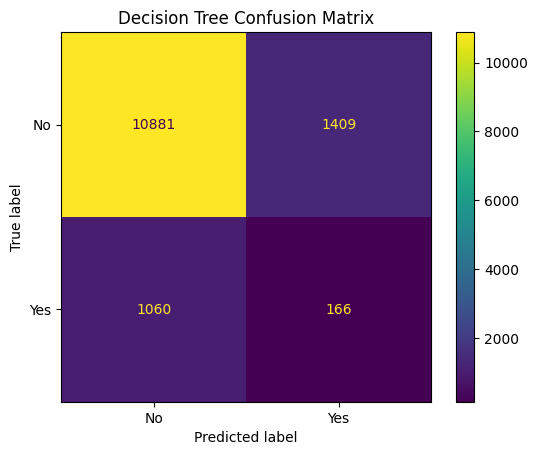

In [56]:
# ============================================================
# 51. DECISION TREE CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=dtree_cm,
    display_labels=[
        'No',
        'Yes'
    ]
)

disp.plot(
    values_format='d'
)

plt.title('Decision Tree Confusion Matrix')
plt.show()

In [57]:
# ============================================================
# 52. DECISION TREE FEATURE IMPORTANCE
# ============================================================

feature_importance_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': dtree.feature_importances_
})

most_imp_features = (
    feature_importance_df
    .nlargest(10, 'Importance')
    .sort_values('Importance')
)

display(most_imp_features)

,Feature,Importance
36,num_medications|number_diagnoses,0.026505
32,num_medications|time_in_hospital,0.026941
3,num_lab_procedures,0.027609
0,gender,0.031935
37,age|number_diagnoses,0.032338
34,time_in_hospital|num_lab_procedures,0.033127
38,change|num_medications,0.036509
35,num_medications|num_lab_procedures,0.040417
25,change,0.096470
31,number_inpatient_log1p,0.201157


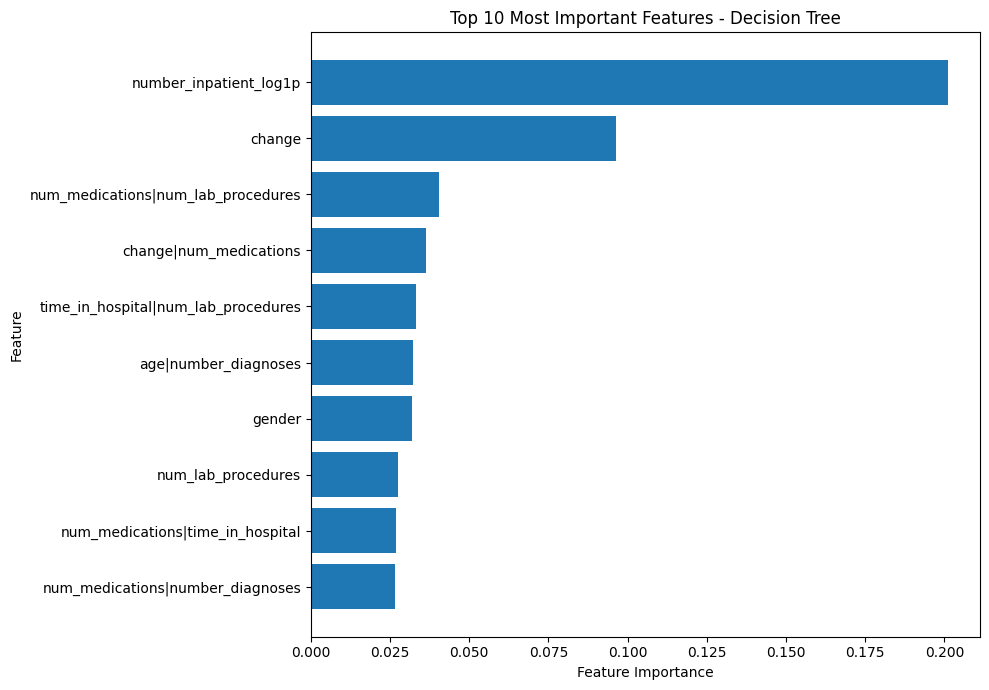

In [58]:
# ============================================================
# 53. TOP 10 DECISION TREE FEATURES
# ============================================================

plt.figure(figsize=(10, 7))

plt.barh(
    most_imp_features['Feature'],
    most_imp_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features - Decision Tree')

plt.tight_layout()
plt.show()

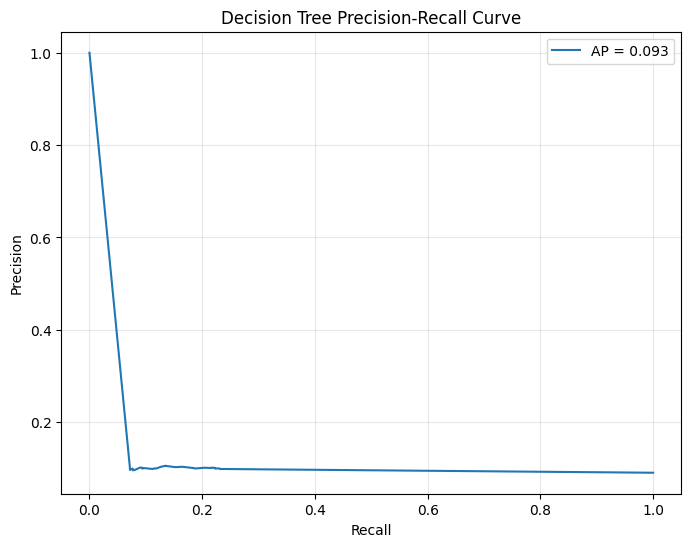

In [59]:
# ============================================================
# 54. PRECISION-RECALL CURVE
# ============================================================

precision_curve, recall_curve, thresholds = (
    precision_recall_curve(
        y_test,
        dtree_pred_proba
    )
)

average_precision = average_precision_score(
    y_test,
    dtree_pred_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f'AP = {average_precision:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Decision Tree Precision-Recall Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

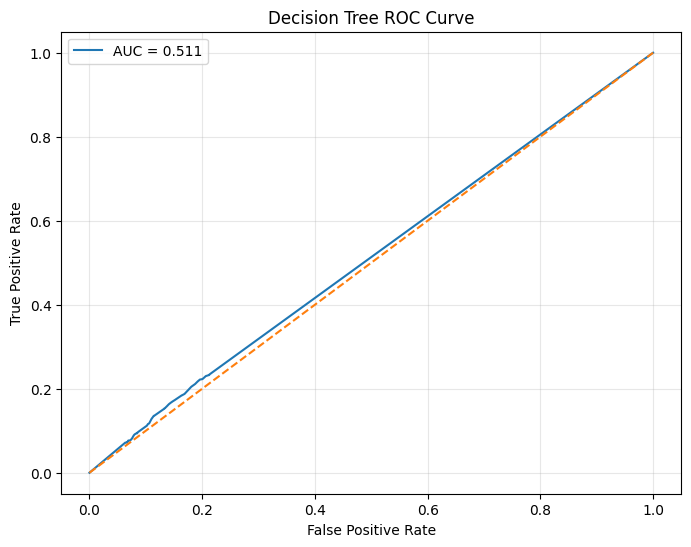

In [60]:
# ============================================================
# 55. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    dtree_pred_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [62]:
# ============================================================
# 56. STORE DECISION TREE RESULTS
# ============================================================

dtree_results = pd.DataFrame({
    'Model': ['Decision Tree'],
    'Accuracy': [accuracy_dtree],
    'Precision': [precision_dtree],
    'Recall': [recall_dtree],
    'ROC_AUC': [roc_auc]
})

display(dtree_results)

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Decision Tree,0.817328,0.105397,0.1354,0.511239


In [63]:
# ============================================================
# 57. SCALE DATA FOR KNN
# ============================================================

scaler = StandardScaler()

X_train_knn = scaler.fit_transform(
    X_train_smote
)

X_test_knn = scaler.transform(
    X_test_raw
)

print("KNN training data:", X_train_knn.shape)
print("KNN testing data:", X_test_knn.shape)

KNN training data: (98322, 73)
KNN testing data: (13516, 73)


In [64]:
# ============================================================
# 58. KNN GRID SEARCH
# ============================================================

param_grid = {
    'n_neighbors': [3, 5],
    'weights': ['uniform'],
    'p': [2]
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring='recall'
)

grid_search.fit(
    X_train_knn,
    y_train_smote
)

print(
    "Best parameters found:",
    grid_search.best_params_
)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters found: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}


In [65]:
# ============================================================
# 59. BEST KNN MODEL
# ============================================================

best_knn = grid_search.best_estimator_

knn_pred = best_knn.predict(
    X_test_knn
)

knn_pred_proba = best_knn.predict_proba(
    X_test_knn
)[:, 1]

print("KNN predictions generated.")

KNN predictions generated.


In [66]:
# ============================================================
# 60. KNN CONFUSION MATRIX
# ============================================================

knn_cm = confusion_matrix(
    y_test,
    knn_pred
)

print("KNN Confusion Matrix:")
print(knn_cm)

KNN Confusion Matrix:
[[11021  1269]
 [ 1077   149]]


In [67]:
# ============================================================
# 61. KNN METRICS
# ============================================================

accuracy_knn = accuracy_score(
    y_test,
    knn_pred
)

precision_knn = precision_score(
    y_test,
    knn_pred,
    zero_division=0
)

recall_knn = recall_score(
    y_test,
    knn_pred,
    zero_division=0
)

print(
    f"Accuracy:  {accuracy_knn:.4f}"
)

print(
    f"Precision: {precision_knn:.4f}"
)

print(
    f"Recall:    {recall_knn:.4f}"
)

Accuracy:  0.8264
Precision: 0.1051
Recall:    0.1215


In [68]:
# ============================================================
# 62. KNN CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=[
            'No Early Readmission',
            'Early Readmission (<30 Days)'
        ],
        zero_division=0
    )
)

                              precision    recall  f1-score   support

        No Early Readmission       0.91      0.90      0.90     12290
Early Readmission (<30 Days)       0.11      0.12      0.11      1226

                    accuracy                           0.83     13516
                   macro avg       0.51      0.51      0.51     13516
                weighted avg       0.84      0.83      0.83     13516



<Figure size 700x600 with 0 Axes>

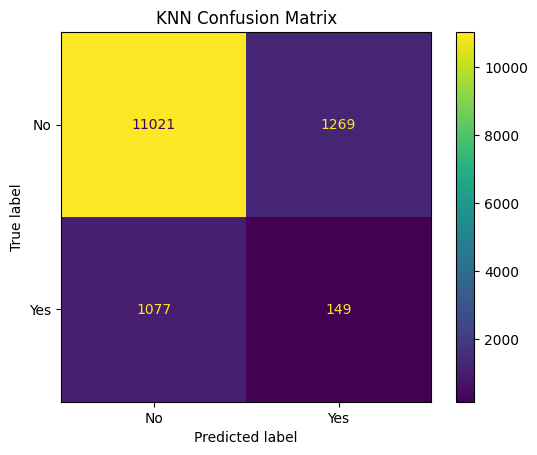

In [69]:
# ============================================================
# 63. KNN CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=[
        'No',
        'Yes'
    ]
)

disp.plot(
    values_format='d'
)

plt.title('KNN Confusion Matrix')

plt.show()

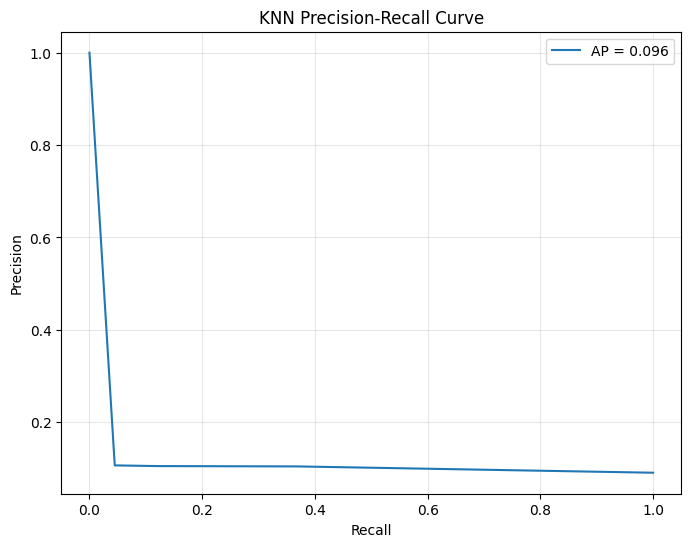

In [70]:
# ============================================================
# 64. KNN PRECISION-RECALL CURVE
# ============================================================

knn_precision_curve, knn_recall_curve, _ = (
    precision_recall_curve(
        y_test,
        knn_pred_proba
    )
)

knn_average_precision = average_precision_score(
    y_test,
    knn_pred_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    knn_recall_curve,
    knn_precision_curve,
    label=f'AP = {knn_average_precision:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('KNN Precision-Recall Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

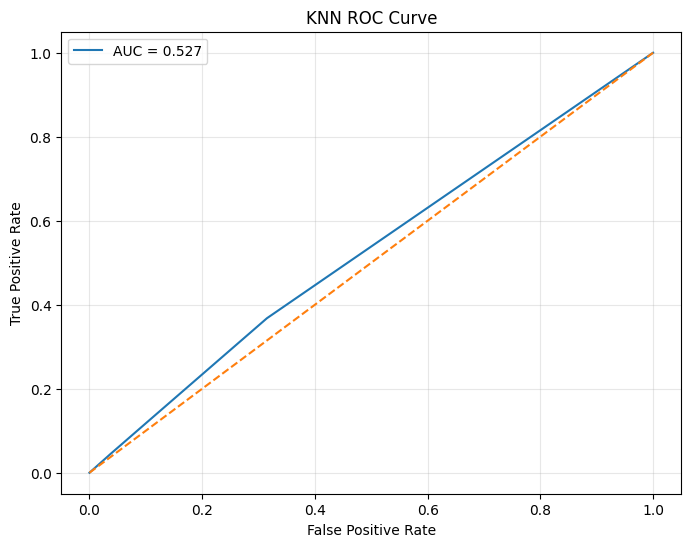

In [71]:
# ============================================================
# 65. KNN ROC CURVE
# ============================================================

knn_fpr, knn_tpr, _ = roc_curve(
    y_test,
    knn_pred_proba
)

knn_roc_auc = auc(
    knn_fpr,
    knn_tpr
)

plt.figure(figsize=(8, 6))

plt.plot(
    knn_fpr,
    knn_tpr,
    label=f'AUC = {knn_roc_auc:.3f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [72]:
# ============================================================
# 66. STORE KNN RESULTS
# ============================================================

knn_results = pd.DataFrame({
    'Model': ['KNN'],
    'Accuracy': [accuracy_knn],
    'Precision': [precision_knn],
    'Recall': [recall_knn],
    'ROC_AUC': [knn_roc_auc]
})

display(knn_results)

,Model,Accuracy,Precision,Recall,ROC_AUC
0,KNN,0.826428,0.105078,0.121533,0.526666


In [73]:
# ============================================================
# 67. COMPARE MODEL RESULTS
# ============================================================

model_comparison = pd.concat(
    [
        dtree_results,
        knn_results
    ],
    ignore_index=True
)

display(model_comparison)

,Model,Accuracy,Precision,Recall,ROC_AUC
0,Decision Tree,0.817328,0.105397,0.135400,0.511239
1,KNN,0.826428,0.105078,0.121533,0.526666


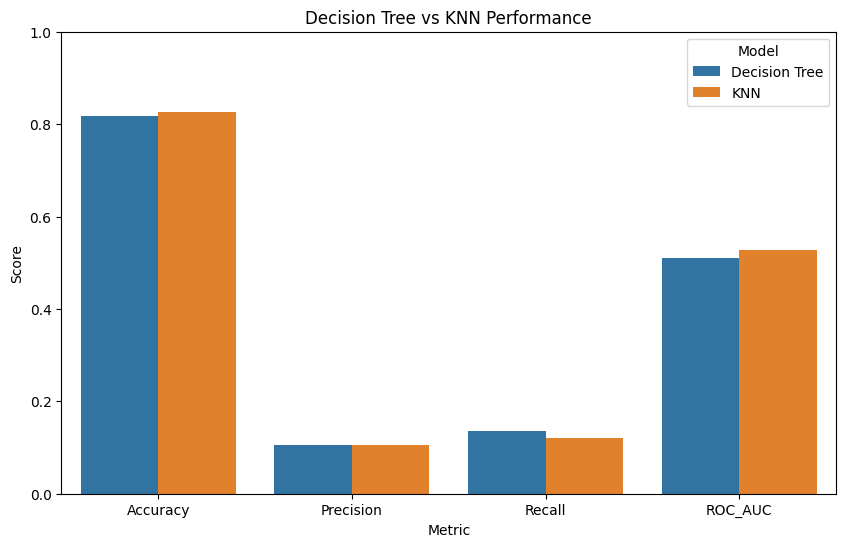

In [74]:
# ============================================================
# 68. MODEL PERFORMANCE COMPARISON
# ============================================================

comparison_long = model_comparison.melt(
    id_vars='Model',
    value_vars=[
        'Accuracy',
        'Precision',
        'Recall',
        'ROC_AUC'
    ],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_long,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.title('Decision Tree vs KNN Performance')

plt.legend(title='Model')

plt.show()

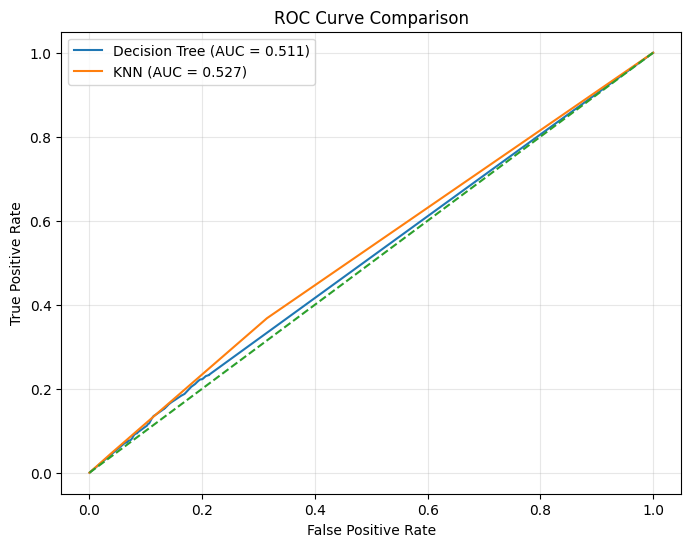

In [75]:
# ============================================================
# 69. ROC CURVE COMPARISON
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Decision Tree (AUC = {roc_auc:.3f})'
)

plt.plot(
    knn_fpr,
    knn_tpr,
    label=f'KNN (AUC = {knn_roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [76]:
# ============================================================
# 70. FINAL MODEL SUMMARY
# ============================================================

print("=" * 60)
print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print("\nDecision Tree")
print("-" * 30)
print(f"Accuracy : {accuracy_dtree:.4f}")
print(f"Precision: {precision_dtree:.4f}")
print(f"Recall   : {recall_dtree:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nKNN")
print("-" * 30)
print(f"Accuracy : {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall   : {recall_knn:.4f}")
print(f"ROC-AUC  : {knn_roc_auc:.4f}")

print("\nBest KNN Parameters:")
print(grid_search.best_params_)

FINAL MODEL PERFORMANCE

Decision Tree
------------------------------
Accuracy : 0.8173
Precision: 0.1054
Recall   : 0.1354
ROC-AUC  : 0.5112

KNN
------------------------------
Accuracy : 0.8264
Precision: 0.1051
Recall   : 0.1215
ROC-AUC  : 0.5267

Best KNN Parameters:
{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}


In [77]:
# ============================================================
# 71. FINAL TOP 10 FEATURES
# ============================================================

print("Top 10 Decision Tree Features:")

display(
    most_imp_features.sort_values(
        by='Importance',
        ascending=False
    )
)

Top 10 Decision Tree Features:


,Feature,Importance
31,number_inpatient_log1p,0.201157
25,change,0.096470
35,num_medications|num_lab_procedures,0.040417
38,change|num_medications,0.036509
34,time_in_hospital|num_lab_procedures,0.033127
37,age|number_diagnoses,0.032338
0,gender,0.031935
3,num_lab_procedures,0.027609
32,num_medications|time_in_hospital,0.026941
36,num_medications|number_diagnoses,0.026505
